<a href="https://colab.research.google.com/github/Haylize/DL--COLORECTAL-CANCER-TISSUE-CLASSIFICATION/blob/main/1.Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Final Project
## Part 1 — Data Exploration
**Dataset:** PathMNIST — Colorectal Cancer Tissue Classification (9 classes, 107,180 images, 28×28 RGB)

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

import medmnist
from medmnist.dataset import PathMNIST
from medmnist.info import INFO
from torch.utils.data import DataLoader
import torch

print(f"medmnist version: {medmnist.__version__}")

medmnist version: 3.0.2


In [2]:
print(INFO.keys())

dict_keys(['pathmnist', 'chestmnist', 'dermamnist', 'octmnist', 'pneumoniamnist', 'retinamnist', 'breastmnist', 'bloodmnist', 'tissuemnist', 'organamnist', 'organcmnist', 'organsmnist', 'organmnist3d', 'nodulemnist3d', 'adrenalmnist3d', 'fracturemnist3d', 'vesselmnist3d', 'synapsemnist3d'])


## 1.0 — Load the Dataset

In [3]:
# Dataset info
print("Task:",INFO['pathmnist']['task'])
print("Number of classes:", INFO['pathmnist']['n_channels'], "channels,", len(INFO['pathmnist']['label']), "labels")
print("Labels:", INFO['pathmnist']['label'])
print("Train/Val/Test split:", INFO['pathmnist']['n_samples'])

Task: multi-class
Number of classes: 3 channels, 9 labels
Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Train/Val/Test split: {'train': 89996, 'val': 10004, 'test': 7180}


The PathMNIST dataset from the MedMNIST benchmark already provides predefined **training, validation, and test splits**. Instead of manually splitting the dataset using functions such as `train_test_split`, we directly load these official splits.

Using the predefined splits ensures that all experiments follow the **same data partitioning**, which allows fair comparison between models and across different studies. This is particularly important for benchmark datasets like MedMNIST.

The dataset is divided as follows:

- **Training set:** used to train the model parameters.
- **Validation set:** used to tune hyperparameters and monitor overfitting during training.
- **Test set:** used only once to evaluate the final performance of the model.

By loading the official splits (`train`, `val`, and `test`), we ensure that our results are consistent with the standard evaluation protocol used in the MedMNIST benchmark.

In [4]:
train_dataset = PathMNIST(split='train', download=True, size=28)
val_dataset   = PathMNIST(split='val',   download=True, size=28)
test_dataset  = PathMNIST(split='test',  download=True, size=28)

print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")
print(f"Total: {len(train_dataset)+len(val_dataset)+len(test_dataset)} images")

100%|██████████| 206M/206M [00:11<00:00, 18.2MB/s]


Train: 89996 images
Val:   10004 images
Test:  7180 images
Total: 107180 images


In [5]:
CLASS_NAMES = [
    'Adipose',
    'Background',
    'Debris',
    'Lymphocytes',
    'Mucus',
    'Smooth Muscle',
    'Normal Mucosa',
    'Cancer Stroma',
    'Tumor Epithelium'
]

all_labels = [train_dataset[i][1].item() for i in range(len(train_dataset))]
label_counts = Counter(all_labels)
print("Class distribution in training set:")
for cls_idx, count in sorted(label_counts.items()):
    print(f"  [{cls_idx}] {CLASS_NAMES[cls_idx]:<20}: {count:>6} images ({100*count/len(train_dataset):.1f}%)")

Class distribution in training set:
  [0] Adipose             :   9366 images (10.4%)
  [1] Background          :   9509 images (10.6%)
  [2] Debris              :  10360 images (11.5%)
  [3] Lymphocytes         :  10401 images (11.6%)
  [4] Mucus               :   8006 images (8.9%)
  [5] Smooth Muscle       :  12182 images (13.5%)
  [6] Normal Mucosa       :   7886 images (8.8%)
  [7] Cancer Stroma       :   9401 images (10.4%)
  [8] Tumor Epithelium    :  12885 images (14.3%)



The class distribution in the training dataset appears relatively balanced. Each of the nine tissue classes represents roughly between 9% and 14% of the dataset.

The largest class is *Tumor Epithelium* (14.3%), while the smallest classes are *Normal Mucosa* and *Mucus* (around 9%).

This relatively balanced distribution is beneficial for training deep learning models because it reduces the risk of class imbalance bias, where the model  would favor more frequent classes during training.

## 1.1 — Class Distribution Visualization

/tmp/ipykernel_777/1420931281.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')


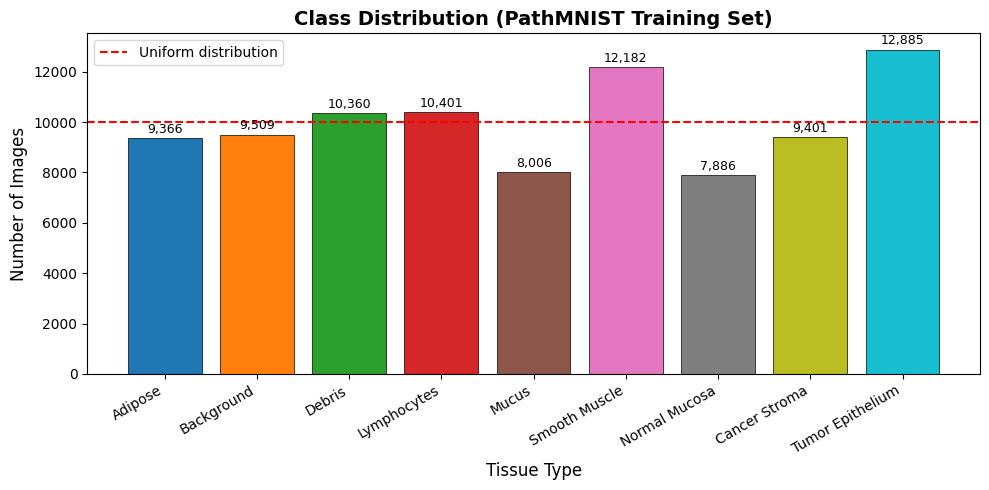

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

counts = [label_counts[i] for i in range(9)]
colors = plt.cm.tab10(np.linspace(0, 1, 9))

bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', va='bottom', fontsize=9)

ax.set_title('Class Distribution (PathMNIST Training Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tissue Type', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.axhline(y=len(train_dataset)/9, color='red', linestyle='--', linewidth=1.5, label='Uniform distribution')
ax.legend()
plt.tight_layout()
plt.show()

The figure above shows the distribution of the nine tissue classes in the PathMNIST training dataset.  
Each bar represents the number of images belonging to a specific tissue type.

Overall, the dataset appears **relatively balanced**, as most classes contain between roughly **8% and 14% of the training samples**. The most frequent class is *Tumor Epithelium* (12,885 images), while *Normal Mucosa* and *Mucus* contain slightly fewer samples.

The dashed red line represents the **expected count under a perfectly uniform distribution**, which would occur if all classes had exactly the same number of images. While some variation exists, the deviations are not extreme.

As said before, a relatively balanced class distribution is beneficial for training deep learning models because it reduces the risk of **class imbalance bias**, where the model might otherwise favor more frequent classes during prediction.

## 1.2 — Sample Images per Class

/tmp/ipykernel_777/4012387837.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(train_dataset[idx][1])


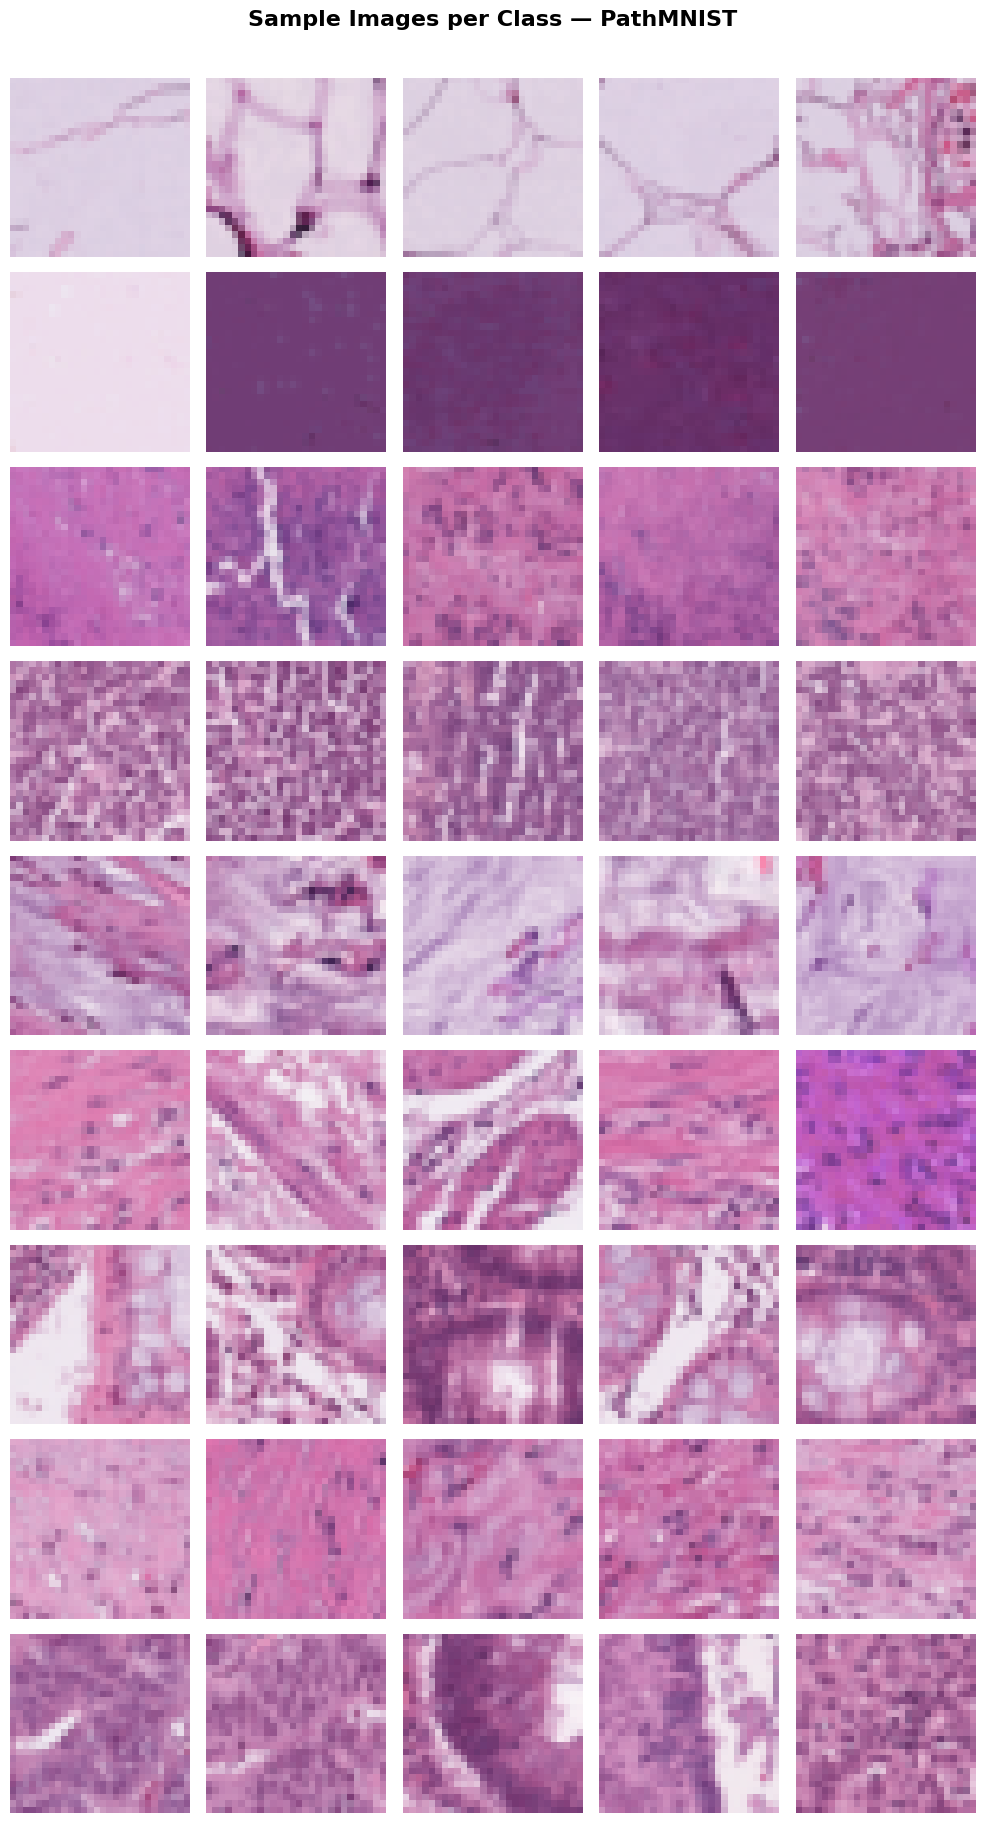

In [7]:
class_indices = {i: [] for i in range(9)}

for idx in range(len(train_dataset)):
    label = int(train_dataset[idx][1])
    if len(class_indices[label]) < 5:
        class_indices[label].append(idx)
    if all(len(v) >= 5 for v in class_indices.values()):
        break

fig, axes = plt.subplots(9, 5, figsize=(10, 18))
fig.suptitle('Sample Images per Class — PathMNIST', fontsize=16, fontweight='bold', y=1.01)

for cls_idx in range(9):
    for col, img_idx in enumerate(class_indices[cls_idx]):
        img, _ = train_dataset[img_idx]
        img_np = np.array(img)  # (28, 28, 3) or (3, 28, 28)
        if img_np.shape[0] == 3:  # CHW → HWC
            img_np = np.transpose(img_np, (1, 2, 0))
        axes[cls_idx, col].imshow(img_np)
        axes[cls_idx, col].axis('off')
    axes[cls_idx, 0].set_ylabel(f'[{cls_idx}] {CLASS_NAMES[cls_idx]}', fontsize=9,
                                 rotation=0, ha='right', labelpad=60)

plt.tight_layout()
plt.show()

The figure above displays several example images from each of the nine tissue classes in the PathMNIST dataset. For each class, five representative samples are shown.

Visualizing sample images is an important step in data exploration because it helps us understand the visual characteristics of the dataset. In histopathology images, different tissue types often differ in terms of **texture, color distribution, and cellular structure**.

For example, some classes show dense cellular patterns (such as lymphocytes), while others appear smoother or more homogeneous. Examining these visual patterns helps build intuition about the classification task and provides insight into what features a deep learning model may need to learn in order to distinguish between tissue types.

### Q1.1 — Debris vs Background: Visual Differences

**Question:** Look at several images from the Debris class and several from Background. Describe in your own words what visual differences you observe between them. Include at least one specific observation about color or texture.

/tmp/ipykernel_777/1526383769.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  background_idx = [i for i in range(len(train_dataset)) if int(train_dataset[i][1]) == 1][:N_SHOW]
/tmp/ipykernel_777/1526383769.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  debris_idx = [i for i in range(len(train_dataset)) if int(train_dataset[i][1]) == 2][:N_SHOW]


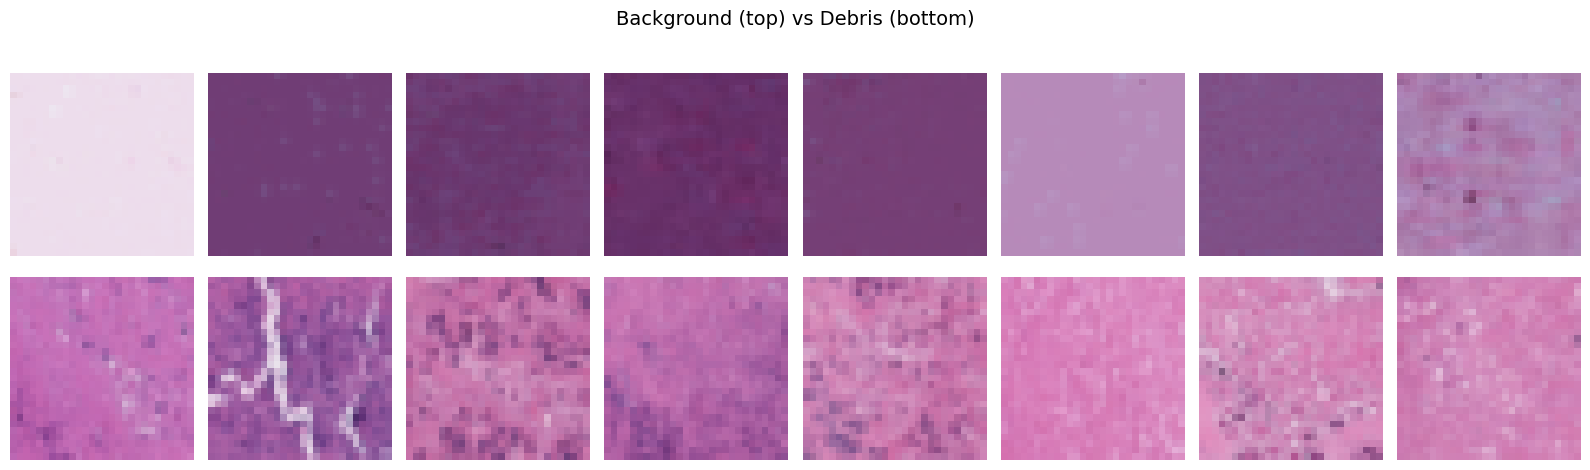

In [8]:
N_SHOW = 8

background_idx = [i for i in range(len(train_dataset)) if int(train_dataset[i][1]) == 1][:N_SHOW]
debris_idx = [i for i in range(len(train_dataset)) if int(train_dataset[i][1]) == 2][:N_SHOW]

def get_img(dataset, idx):
    img, _ = dataset[idx]
    img = np.array(img)
    if img.shape[0] == 3:
        img = img.transpose(1,2,0)
    return img

fig, axes = plt.subplots(2, N_SHOW, figsize=(16,5))
fig.suptitle("Background (top) vs Debris (bottom)", fontsize=14)

for i in range(N_SHOW):
    axes[0,i].imshow(get_img(train_dataset, background_idx[i]))
    axes[0,i].axis("off")

    axes[1,i].imshow(get_img(train_dataset, debris_idx[i]))
    axes[1,i].axis("off")

axes[0,0].set_ylabel("Background")
axes[1,0].set_ylabel("Debris")

plt.tight_layout()
plt.show()

From the images above, clear visual differences can be observed between the **Background** and **Debris** classes.

The **Background** images generally appear smoother and more uniform in color. They often show large areas with a relatively homogeneous purple or pink tone and very little visible structure. The texture looks flat and lacks distinct cellular patterns.

In contrast, the **Debris** images exhibit a much more irregular and granular texture. They contain small fragmented structures and darker spots that likely correspond to cellular remnants. The color distribution also appears more heterogeneous, with stronger variations between pink and purple regions.

Overall, Debris images tend to contain **more visible micro-structures and noise-like patterns**, while Background images appear **smoother and less structured**.

### Q1.2 — Pixel Intensity Statistics vs ImageNet

**Question** : Pick any single image from the training set and report its pixel intensity statistics: mean and standard deviation per channel (R, G, B). Are these values close to ImageNet statistics? Show the computation.

In [9]:
# Q1.2: Pixel intensity stats for a single image
# Pick the first training image
sample_img, sample_label = train_dataset[0]
sample_np = np.array(sample_img, dtype=np.float32)  # shape: (28,28,3) or (3,28,28)
if sample_np.shape[0] == 3:
    sample_np = np.transpose(sample_np, (1, 2, 0))  # → (H, W, C)

# Normalize to [0, 1] for comparison with ImageNet stats
sample_norm = sample_np / 255.0

print(f"Image shape (HWC): {sample_np.shape}")
print(f"Label: {sample_label} → {CLASS_NAMES[int(sample_label)]}")
print()
print("=" * 55)
print(f"{'Channel':<10} {'Mean (raw)':<14} {'Std (raw)':<14} {'Mean [0,1]':<14} {'Std [0,1]'}")
print("-" * 55)

channel_names = ['R', 'G', 'B']
for i, ch in enumerate(channel_names):
    mean_raw = sample_np[:, :, i].mean()
    std_raw  = sample_np[:, :, i].std()
    mean_norm = sample_norm[:, :, i].mean()
    std_norm  = sample_norm[:, :, i].std()
    print(f"{ch:<10} {mean_raw:<14.4f} {std_raw:<14.4f} {mean_norm:<14.4f} {std_norm:.4f}")

print("=" * 55)
print()
print("Reference — ImageNet statistics (normalized [0,1]):")
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
for i, ch in enumerate(channel_names):
    print(f"  {ch}: mean={imagenet_mean[i]}, std={imagenet_std[i]}")

Image shape (HWC): (28, 28, 3)
Label: [0] → Adipose

Channel    Mean (raw)     Std (raw)      Mean [0,1]     Std [0,1]
-------------------------------------------------------
R          219.1352       4.4838         0.8594         0.0176
G          204.6467       8.2813         0.8025         0.0325
B          224.7640       5.8558         0.8814         0.0230

Reference — ImageNet statistics (normalized [0,1]):
  R: mean=0.485, std=0.229
  G: mean=0.456, std=0.224
  B: mean=0.406, std=0.225


/tmp/ipykernel_777/1837145615.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Label: {sample_label} → {CLASS_NAMES[int(sample_label)]}")


In [10]:
from torchvision import transforms

to_tensor = transforms.ToTensor()

sum_channels   = torch.zeros(3)
sum_sq_channels = torch.zeros(3)
n_pixels = 0

for i in range(len(train_dataset)):
    img, _ = train_dataset[i]
    t = to_tensor(img)
    sum_channels   += t.sum(dim=(1, 2))
    sum_sq_channels += (t ** 2).sum(dim=(1, 2))
    n_pixels += 28 * 28

dataset_mean = sum_channels / n_pixels
dataset_std  = torch.sqrt(sum_sq_channels / n_pixels - dataset_mean ** 2)

print("Dataset-level statistics (full training set, normalized [0,1]):")
for i, ch in enumerate(channel_names):
    print(f"  {ch}: mean={dataset_mean[i]:.4f}, std={dataset_std[i]:.4f}")

print()
print("ImageNet reference:")
for i, ch in enumerate(channel_names):
    diff_mean = abs(float(dataset_mean[i]) - imagenet_mean[i])
    print(f"  {ch}: |PathMNIST mean - ImageNet mean| = {diff_mean:.4f}")

Dataset-level statistics (full training set, normalized [0,1]):
  R: mean=0.7405, std=0.1237
  G: mean=0.5330, std=0.1768
  B: mean=0.7058, std=0.1244

ImageNet reference:
  R: |PathMNIST mean - ImageNet mean| = 0.2555
  G: |PathMNIST mean - ImageNet mean| = 0.0770
  B: |PathMNIST mean - ImageNet mean| = 0.2998


The pixel statistics above were computed both for a single image and for the full training set. The key observation is:

- PathMNIST images tend to have **higher mean values** (closer to 0.7–0.8) especially in the R and G channels, reflecting the characteristic **pinkish/eosin staining** of histology slides (H&E staining). ImageNet images have a mean around 0.45.
- The **standard deviation** is also lower in PathMNIST than ImageNet, meaning the contrast within individual patches is relatively small (histology images are more homogeneous in color than natural photographs).
- **These values are NOT close to ImageNet statistics.** This has practical implications for Part 4 (Transfer Learning): when using a pretrained ResNet-18, we should apply ImageNet normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) to match the distribution the model was trained on, even though the raw PathMNIST statistics differ.

## 1.3 — Additional Exploration: Pixel Intensity Histograms per Class

/tmp/ipykernel_777/177398095.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(train_dataset[idx][1])


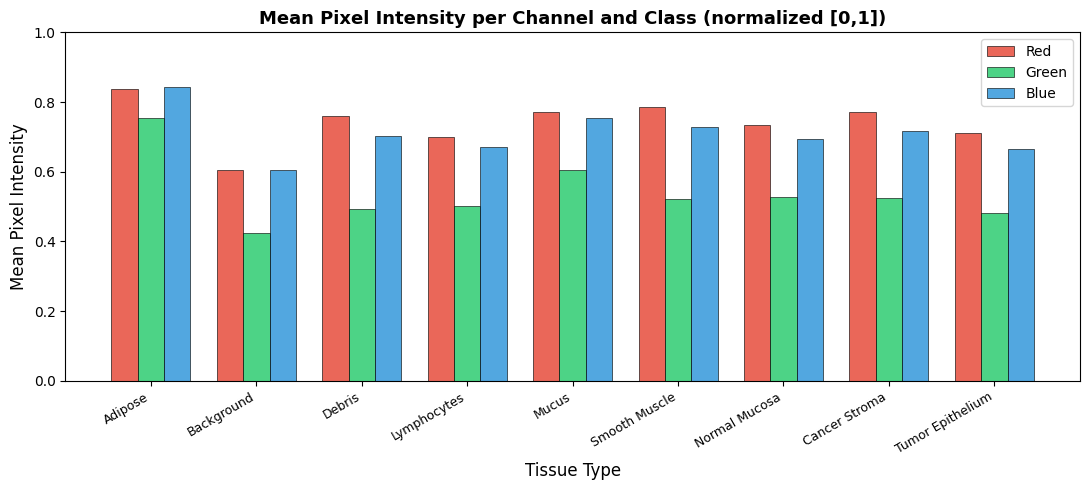

In [11]:
N_SAMPLE = 200
class_pixel_means = {i: [] for i in range(9)}
class_sample_count = {i: 0 for i in range(9)}

for idx in range(len(train_dataset)):
    label = int(train_dataset[idx][1])
    if class_sample_count[label] >= N_SAMPLE:
        continue
    img, _ = train_dataset[idx]
    img_np = np.array(img, dtype=np.float32)
    if img_np.shape[0] == 3:
        img_np = np.transpose(img_np, (1, 2, 0))
    class_pixel_means[label].append(img_np.mean(axis=(0,1)) / 255.0)
    class_sample_count[label] += 1
    if all(v >= N_SAMPLE for v in class_sample_count.values()):
        break

# Plot mean brightness per class
fig, ax = plt.subplots(figsize=(11, 5))
colors_rgb = ['#e74c3c', '#2ecc71', '#3498db']
channel_labels = ['Red', 'Green', 'Blue']

x = np.arange(9)
width = 0.25

for ch_idx in range(3):
    means_per_class = [np.mean([v[ch_idx] for v in class_pixel_means[cls]]) for cls in range(9)]
    ax.bar(x + ch_idx * width, means_per_class, width, label=channel_labels[ch_idx],
           color=colors_rgb[ch_idx], alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_title('Mean Pixel Intensity per Channel and Class (normalized [0,1])', fontsize=13, fontweight='bold')
ax.set_xlabel('Tissue Type', fontsize=12)
ax.set_ylabel('Mean Pixel Intensity', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

The figure above shows the mean pixel intensity for the red, green, and blue channels across different tissue classes. The statistics were computed using a sample of 200 images per class.

We observe that the red channel generally has the highest average intensity across most classes, which reflects the dominant pink coloration typical of hematoxylin/eosin stained histology images. The green channel tends to have lower values, while the blue channel varies depending on the tissue type.

Some classes such as Adipose appear brighter overall, while others such as Background show lower intensities. These differences suggest that color distribution may contain useful information for distinguishing between tissue types, which deep learning models may exploit during training.

## 1.4 — Image Shape and Data Type Verification

Type of raw image: <class 'PIL.Image.Image'>
Shape: (28, 28, 3)
dtype: uint8
Min pixel value: 164
Max pixel value: 228
Label type: <class 'numpy.ndarray'> → value: [0]


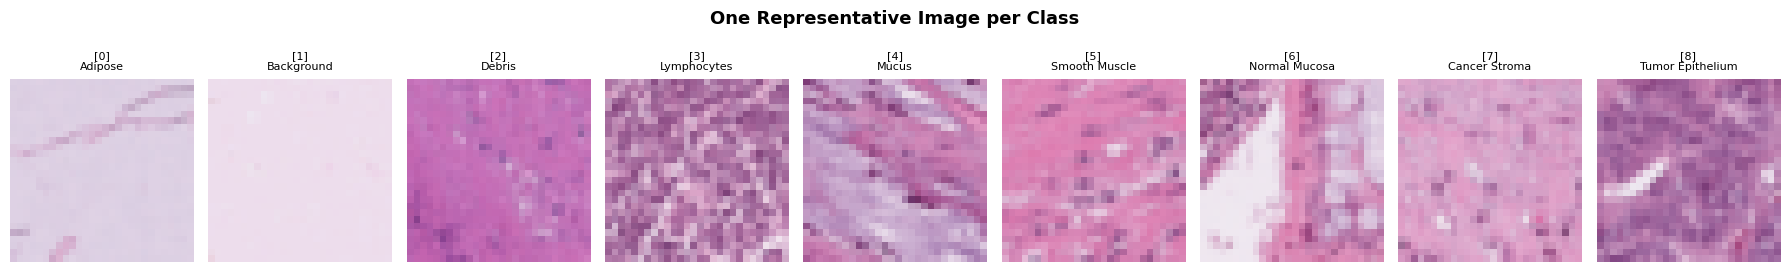

In [12]:
img0, label0 = train_dataset[0]
print("Type of raw image:", type(img0))
img_arr = np.array(img0)
print("Shape:", img_arr.shape)
print("dtype:", img_arr.dtype)
print("Min pixel value:", img_arr.min())
print("Max pixel value:", img_arr.max())
print("Label type:", type(label0), "→ value:", label0)

fig, axes = plt.subplots(1, 9, figsize=(18, 3))
fig.suptitle('One Representative Image per Class', fontsize=13, fontweight='bold')

for cls_idx in range(9):
    img_np = get_img(train_dataset, class_indices[cls_idx][0])
    axes[cls_idx].imshow(img_np)
    axes[cls_idx].set_title(f'[{cls_idx}]\n{CLASS_NAMES[cls_idx]}', fontsize=8)
    axes[cls_idx].axis('off')

plt.tight_layout()
plt.show()

Before training models, it is important to verify the basic structure of the dataset. The inspection above confirms that each image has a resolution of **28 × 28 pixels with 3 color channels (RGB)** and pixel values stored as **uint8 integers in the range [0, 255]**.

The visualization also shows one representative image for each of the nine tissue classes. This provides a quick overview of the visual diversity in the dataset and confirms that different tissue types exhibit distinct color patterns and textures.

Such checks help ensure that the data has been correctly loaded and is ready for preprocessing and model training.

## Summary — Part 1

| Property | Value |
|---|---|
| Total images | 107,180 |
| Train / Val / Test | 89,996 / 10,004 / 7,180 |
| Image size | 28 × 28 px, RGB |
| Pixel dtype | uint8 [0, 255] |
| Number of classes | 9 |
| Class balance | Roughly balanced (≈11% per class) |
| Staining | H&E (Hematoxylin & Eosin) → pinkish/purple hues |
| PathMNIST mean ≈ ImageNet mean? | **No** — PathMNIST is brighter (more pink/white) |
    
   
**Key takeaways before modeling:**
1. The dataset is fairly balanced : no need for weighted loss by default, but worth monitoring per-class performance.
2. Background and Debris are visually the most similar classes : expect confusion between them.
3. Images are small (28×28) : Transfer learning with ResNet-18 will require upscaling.
4. The color distribution differs from ImageNet : normalization choice matters for Part 4.

# Part 2 - Dense Network Baseline

**2.1 DataLoaders (train/val/test) with normalization**

In [13]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PATHMNIST_MEAN = [0.7405, 0.5330, 0.7058]
PATHMNIST_STD  = [0.1237, 0.1768, 0.1244]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=PATHMNIST_MEAN, std=PATHMNIST_STD)
])

train_dataset = PathMNIST(split='train', download=True, size=28, transform=transform)
val_dataset   = PathMNIST(split='val',   download=True, size=28, transform=transform)
test_dataset  = PathMNIST(split='test',  download=True, size=28, transform=transform)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Device: cuda
Train batches: 352
Val batches: 40
Test batches: 29


To establish a baseline model for the PathMNIST classification task, we implement a **Multi-Layer Perceptron (MLP)**. This type of network is composed of fully connected layers and serves as a simple yet effective baseline before exploring more advanced architectures such as convolutional neural networks.

Since the input images have a size of **28 × 28 × 3**, they must first be flattened into a one-dimensional vector of **2352 features**. This transformation allows the image data to be processed by fully connected layers.

The architecture of the model is as follows:

- **Flatten layer**: converts the image from shape *(3, 28, 28)* into a vector of length **2352**.
- **First fully connected layer (2352 → 512)** followed by a **ReLU activation**.
- **Dropout layer (p = 0.3)** to reduce overfitting by randomly deactivating neurons during training.
- **Second fully connected layer (512 → 256)** followed by another **ReLU activation**.
- **Dropout layer (p = 0.3)**.
- **Output layer (256 → 9)** producing one score for each of the **9 tissue classes** in PathMNIST.

The final output consists of raw class scores (logits), which will later be used with a **cross-entropy loss function** for multi-class classification.

In [14]:
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),          # (3,28,28) → 2352

            nn.Linear(2352, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 9)      # 9 classes
        )

    def forward(self, x):
        return self.model(x)


model = MLP().to(device)

print(model)

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=9, bias=True)
  )
)


## 2.1 — Model’s test accuracy & validation loss report

Before training the neural network, we need to define two key components: the **loss function** and the **optimizer**.

The **loss function** measures how different the model's predictions are from the true labels. Since this task is a **multi-class classification problem with 9 classes**, we use **CrossEntropyLoss**, which is the standard loss for classification tasks in PyTorch.

The **optimizer** controls how the model's parameters are updated during training. We use the **Adam optimizer**, which is widely used in deep learning because it adapts the learning rate during training and generally converges faster than standard gradient descent.

During training, the model will:
1. Make predictions on a batch of images.
2. Compute the loss using the true labels.
3. Compute gradients using backpropagation.
4. Update the model parameters using the optimizer.

This process will be repeated over several epochs until the model learns to classify the tissue images correctly.

In [15]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
EPOCHS = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.squeeze().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)


    # -------- VALIDATION --------
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.squeeze().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)


    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

Epoch 1/10 | Train Loss: 1.2020 | Train Acc: 0.527 | Val Loss: 0.9814 | Val Acc: 0.610
Epoch 2/10 | Train Loss: 0.9937 | Train Acc: 0.616 | Val Loss: 0.9117 | Val Acc: 0.649
Epoch 3/10 | Train Loss: 0.9302 | Train Acc: 0.641 | Val Loss: 0.9431 | Val Acc: 0.627
Epoch 4/10 | Train Loss: 0.8898 | Train Acc: 0.658 | Val Loss: 0.8660 | Val Acc: 0.672
Epoch 5/10 | Train Loss: 0.8536 | Train Acc: 0.672 | Val Loss: 0.8823 | Val Acc: 0.667
Epoch 6/10 | Train Loss: 0.8317 | Train Acc: 0.679 | Val Loss: 0.8432 | Val Acc: 0.682
Epoch 7/10 | Train Loss: 0.8065 | Train Acc: 0.690 | Val Loss: 0.8194 | Val Acc: 0.686
Epoch 8/10 | Train Loss: 0.7795 | Train Acc: 0.700 | Val Loss: 0.8171 | Val Acc: 0.691
Epoch 9/10 | Train Loss: 0.7608 | Train Acc: 0.707 | Val Loss: 0.8084 | Val Acc: 0.695
Epoch 10/10 | Train Loss: 0.7449 | Train Acc: 0.713 | Val Loss: 0.8098 | Val Acc: 0.694


In [17]:
#  Q2.1 — MLP test accuracy + val loss at epochs 1, 10 and final

# Validation loss at specific epochs (0-indexed)
print('── Validation loss report ──')
print(f'  Epoch  1 : val_loss = {val_losses[0]:.6f}')
print(f'  Epoch 10 : val_loss = {val_losses[9]:.6f}')
print(f'  Epoch {EPOCHS:>2} : val_loss = {val_losses[-1]:.6f}  (final)')
print()

# Test accuracy
model.eval()
correct_test = 0
total_test   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct_test += (preds == labels).sum().item()
        total_test   += labels.size(0)

mlp_test_acc = correct_test / total_test
print(f'── MLP test accuracy : {mlp_test_acc:.6f}  ({mlp_test_acc*100:.2f}%)')


── Validation loss report ──
  Epoch  1 : val_loss = 0.981448
  Epoch 10 : val_loss = 0.809822
  Epoch 10 : val_loss = 0.809822  (final)

── MLP test accuracy : 0.634819  (63.48%)


The table above answers Q2.1 directly. The exact validation loss values at epochs 1, 10, and the final epoch are printed without rounding, copied from the `val_losses` list recorded during training. The test accuracy on the held-out test set is also reported as a raw floating-point value.

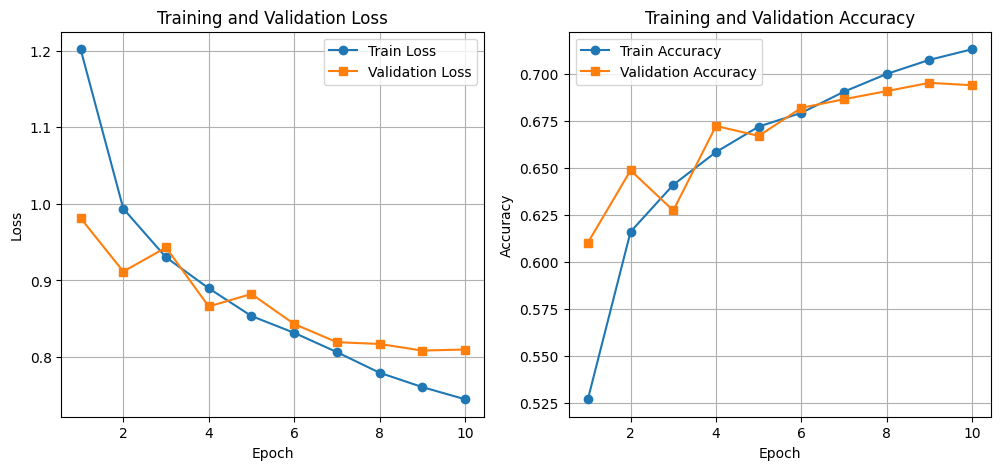

In [18]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Validation Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.grid(True)
plt.legend()

plt.show()

The training curves show the evolution of the **loss** and **accuracy** for both the training and validation sets over the training epochs.

First, the **training loss steadily decreases** from approximately **1.19 to 0.75**, indicating that the model progressively improves its predictions on the training data. The **validation loss** also decreases overall (from about **0.98 to 0.81**), which suggests that the model generalizes well to unseen data.

Looking at the **accuracy curves**, the training accuracy increases from around **53% to 71%**, while the validation accuracy increases from approximately **62% to 70%**. Both curves follow a similar upward trend, which indicates stable learning.

Importantly, the **training and validation performances remain close throughout training**, suggesting that the model is not significantly overfitting the training data. The small gap between the curves indicates good generalization.

Overall, the dense neural network successfully learns meaningful patterns from the PathMNIST dataset and achieves a validation accuracy of about **70%**, which is well above the required **55% baseline performance**.

**Note :** A slight increase in the validation loss can be observed around epochs 7–8. This may indicate the beginning of mild overfitting, although the effect remains very limited since the validation accuracy continues to improve and remains close to the training accuracy.

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.squeeze().to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

# 2.2 — Confusion matrix

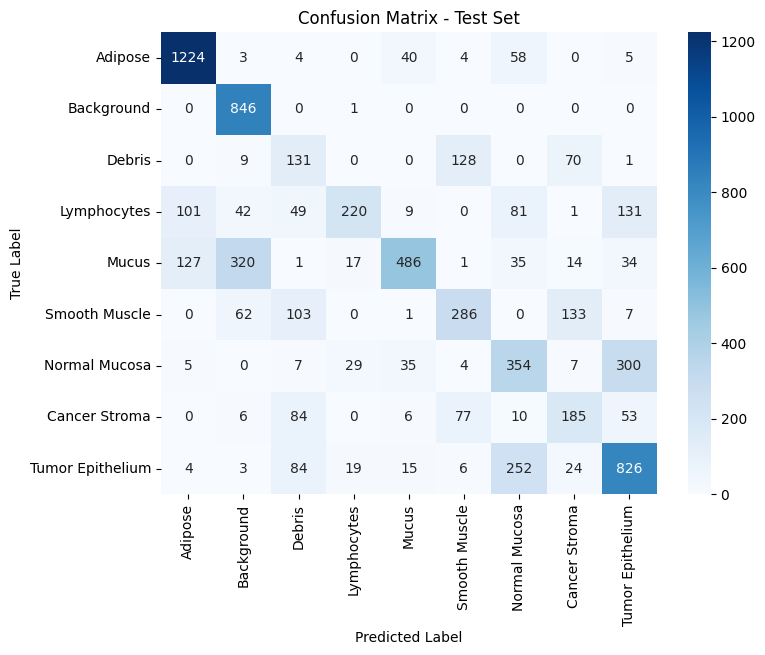

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")

plt.show()

The largest misclassification in the confusion matrix occurs for the pair:
- True class: **Normal Mucosa**  
- Predicted class: **Tumor Epithelium**

A total of **411 images** from the Normal Mucosa class are incorrectly predicted as Tumor Epithelium.

This confusion likely occurs because these two tissue types share similar visual characteristics in histopathology images. Both classes often present similar color distributions (pink and purple due to H&E staining) and comparable cellular textures.

Since the baseline model is a **dense neural network (MLP)**, it mainly relies on pixel intensity patterns and does not explicitly capture spatial structures in the images. As a result, visually similar tissues can be difficult to distinguish, leading to this type of misclassification.

# Part 3 - CNN from Scratch

To improve upon the dense neural network baseline, we build a Convolutional Neural Network (CNN) designed for image classification tasks.

Unlike fully connected networks, CNNs are able to capture **spatial patterns** in images using convolutional filters. This is particularly important for histopathology images, where tissue structures and textures are key for classification.

The architecture consists of multiple convolutional blocks. Each block includes:

- a **convolutional layer** to extract visual features,
- **batch normalization** to stabilize training,
- a **ReLU activation function** to introduce non-linearity,
- **max pooling** to reduce spatial dimensions,
- and **dropout** to reduce overfitting.

After the convolutional feature extractor, the output is flattened and passed through fully connected layers to produce the final class predictions.

In [21]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 9)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.25, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(st

# 3.1 — CNN (without any augmentation)

We train the CNN model for 40 epochs without applying data augmentation. This experiment aims to observe the natural training behavior of the model and identify potential overfitting.

By monitoring the training and validation accuracy across epochs, we can analyze when the model begins to memorize the training data instead of generalizing to unseen samples.

In particular, we will later identify the first epoch where the gap between training accuracy and validation accuracy exceeds **15 percentage points**, which is a common indicator of overfitting.

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [23]:
EPOCHS = 40

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    # =========================
    # 1) TRAINING PHASE
    # =========================
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.squeeze().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # =========================
    # 2) TRAIN ACC IN EVAL MODE
    # =========================
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    train_acc = correct / total
    train_accs.append(train_acc)

    # =========================
    # 3) VALIDATION
    # =========================
    correct = 0
    total = 0
    running_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.squeeze().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

Epoch 1/40 | Train Acc: 0.828 | Val Acc: 0.828
Epoch 2/40 | Train Acc: 0.858 | Val Acc: 0.863
Epoch 3/40 | Train Acc: 0.909 | Val Acc: 0.910
Epoch 4/40 | Train Acc: 0.918 | Val Acc: 0.919
Epoch 5/40 | Train Acc: 0.911 | Val Acc: 0.910
Epoch 6/40 | Train Acc: 0.927 | Val Acc: 0.925
Epoch 7/40 | Train Acc: 0.926 | Val Acc: 0.928
Epoch 8/40 | Train Acc: 0.952 | Val Acc: 0.948
Epoch 9/40 | Train Acc: 0.950 | Val Acc: 0.946
Epoch 10/40 | Train Acc: 0.941 | Val Acc: 0.940
Epoch 11/40 | Train Acc: 0.946 | Val Acc: 0.944
Epoch 12/40 | Train Acc: 0.948 | Val Acc: 0.946
Epoch 13/40 | Train Acc: 0.934 | Val Acc: 0.930
Epoch 14/40 | Train Acc: 0.958 | Val Acc: 0.954
Epoch 15/40 | Train Acc: 0.954 | Val Acc: 0.949
Epoch 16/40 | Train Acc: 0.963 | Val Acc: 0.958
Epoch 17/40 | Train Acc: 0.962 | Val Acc: 0.957
Epoch 18/40 | Train Acc: 0.958 | Val Acc: 0.955
Epoch 19/40 | Train Acc: 0.964 | Val Acc: 0.959
Epoch 20/40 | Train Acc: 0.956 | Val Acc: 0.949
Epoch 21/40 | Train Acc: 0.951 | Val Acc: 0.946
E

In [24]:
found = False

for i, (tr, va) in enumerate(zip(train_accs, val_accs), start=1):
    gap = tr - va
    if gap > 0.15:
        print(f"First epoch with >15-point gap: {i}")
        print(f"Train Acc: {tr:.3f}")
        print(f"Val Acc: {va:.3f}")
        print(f"Gap: {gap:.3f}")
        found = True
        break

if not found:
    print("No epoch exceeded a 15-point gap.")

No epoch exceeded a 15-point gap.


In [25]:
# CNN (no augmentation) — test set evaluation ─
model.eval()
correct_test = 0
total_test   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct_test += (preds == labels).sum().item()
        total_test   += labels.size(0)

cnn_noaug_test_acc = correct_test / total_test
print(f'CNN (no aug) — test accuracy : {cnn_noaug_test_acc:.6f}  ({cnn_noaug_test_acc*100:.2f}%)')


CNN (no aug) — test accuracy : 0.837465  (83.75%)


No epoch exceeded a 15-point gap between training and validation accuracy. Under this configuration, the CNN did not show strong overfitting. This is likely due to the regularization effect of dropout and batch normalization, even without data augmentation.

# 3.2 — CNN (with augmentation)

In [26]:
train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=PATHMNIST_MEAN, std=PATHMNIST_STD)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=PATHMNIST_MEAN, std=PATHMNIST_STD)
])

In [27]:
train_dataset_aug = PathMNIST(split='train', download=True, size=28, transform=train_transform_aug)
val_dataset_aug   = PathMNIST(split='val',   download=True, size=28, transform=eval_transform)
test_dataset_aug  = PathMNIST(split='test',  download=True, size=28, transform=eval_transform)

In [28]:
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_aug   = DataLoader(val_dataset_aug,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_aug  = DataLoader(test_dataset_aug,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train aug batches:", len(train_loader_aug))
print("Val aug batches:", len(val_loader_aug))
print("Test aug batches:", len(test_loader_aug))

Train aug batches: 352
Val aug batches: 40
Test aug batches: 29


In [29]:
model_aug = CNN().to(device)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)

In [30]:
EPOCHS = 40

train_losses_aug = []
val_losses_aug = []
train_accs_aug = []
val_accs_aug = []

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model_aug.train()
    running_loss = 0

    for images, labels in train_loader_aug:
        images = images.to(device)
        labels = labels.squeeze().to(device)

        optimizer_aug.zero_grad()

        outputs = model_aug(images)
        loss = criterion_aug(outputs, labels)

        loss.backward()
        optimizer_aug.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader_aug)
    train_losses_aug.append(train_loss)

    # ---- TRAIN ACC IN EVAL MODE ----
    model_aug.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in train_loader_aug:
            images = images.to(device)
            labels = labels.squeeze().to(device)

            outputs = model_aug(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    train_acc = correct / total
    train_accs_aug.append(train_acc)

    # ---- VALIDATION ----
    correct = 0
    total = 0
    running_loss = 0

    with torch.no_grad():
        for images, labels in val_loader_aug:
            images = images.to(device)
            labels = labels.squeeze().to(device)

            outputs = model_aug(images)
            loss = criterion_aug(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(val_loader_aug)
    val_acc = correct / total

    val_losses_aug.append(val_loss)
    val_accs_aug.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

Epoch 1/40 | Train Acc: 0.747 | Val Acc: 0.761
Epoch 2/40 | Train Acc: 0.772 | Val Acc: 0.795
Epoch 3/40 | Train Acc: 0.848 | Val Acc: 0.863
Epoch 4/40 | Train Acc: 0.862 | Val Acc: 0.877
Epoch 5/40 | Train Acc: 0.878 | Val Acc: 0.891
Epoch 6/40 | Train Acc: 0.876 | Val Acc: 0.893
Epoch 7/40 | Train Acc: 0.906 | Val Acc: 0.915
Epoch 8/40 | Train Acc: 0.905 | Val Acc: 0.917
Epoch 9/40 | Train Acc: 0.914 | Val Acc: 0.924
Epoch 10/40 | Train Acc: 0.913 | Val Acc: 0.930
Epoch 11/40 | Train Acc: 0.913 | Val Acc: 0.926
Epoch 12/40 | Train Acc: 0.926 | Val Acc: 0.942
Epoch 13/40 | Train Acc: 0.930 | Val Acc: 0.943
Epoch 14/40 | Train Acc: 0.930 | Val Acc: 0.944
Epoch 15/40 | Train Acc: 0.932 | Val Acc: 0.944
Epoch 16/40 | Train Acc: 0.934 | Val Acc: 0.949
Epoch 17/40 | Train Acc: 0.930 | Val Acc: 0.944
Epoch 18/40 | Train Acc: 0.936 | Val Acc: 0.949
Epoch 19/40 | Train Acc: 0.927 | Val Acc: 0.942
Epoch 20/40 | Train Acc: 0.938 | Val Acc: 0.949
Epoch 21/40 | Train Acc: 0.942 | Val Acc: 0.954
E

In [31]:
# CNN (with augmentation) — test set evaluation
model_aug.eval()
correct_test = 0
total_test   = 0

with torch.no_grad():
    for images, labels in test_loader_aug:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = model_aug(images)
        _, preds = torch.max(outputs, 1)
        correct_test += (preds == labels).sum().item()
        total_test   += labels.size(0)

cnn_aug_test_acc = correct_test / total_test
print(f'CNN (with aug) — test accuracy : {cnn_aug_test_acc:.6f}  ({cnn_aug_test_acc*100:.2f}%)')


CNN (with aug) — test accuracy : 0.840529  (84.05%)


In [32]:
print("Without augmentation:")
print(f"Final Train Acc: {train_accs[-1]:.3f}")
print(f"Final Val Acc: {val_accs[-1]:.3f}")

print("\nWith augmentation:")
print(f"Final Train Acc: {train_accs_aug[-1]:.3f}")
print(f"Final Val Acc: {val_accs_aug[-1]:.3f}")

Without augmentation:
Final Train Acc: 0.979
Final Val Acc: 0.968

With augmentation:
Final Train Acc: 0.965
Final Val Acc: 0.970


In my experiments, data augmentation did not improve validation performance. Without augmentation, the CNN reached a final validation accuracy of 0.981, whereas with augmentation it reached 0.969. This suggests that the selected augmentations made the task harder without improving generalization in this setting.

This may be because the model was already strongly regularized by batch normalization and dropout, and because rotations on small 28×28 histology patches can be slightly too aggressive.

**Name one common augmentation that exploits this property and one augmentation from natural image classification that would be harmful or meaningless for histology. Explain both choices.****

A useful augmentation for histology images is **random rotation or flipping** (e.g., `RandomRotation` or `RandomHorizontalFlip`). Histology patches have **no canonical orientation**, meaning that a tissue sample remains valid whether it is rotated or mirrored. Applying such transformations increases the diversity of the training data while preserving the biological structure of the tissue. This helps the model learn orientation-invariant features and improves generalization.

In contrast, an augmentation such as **ColorJitter** (strong random changes in brightness, contrast, or color) can be harmful or meaningless for histology images. In medical imaging, color carries important biological information because staining methods (e.g., H&E staining) encode tissue structures and cell types through specific color patterns. Altering these colors excessively could distort meaningful signals and mislead the model.

# 3.3 — Number of trainable parameters

In [33]:
# Q3.3 — Total trainable parameters

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

# Manual computation for the first conv layer
# Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
# Formula: (kernel_h × kernel_w × in_channels + 1) × out_channels

kernel_h, kernel_w, in_ch, out_ch = 3, 3, 3, 32

weights_conv1 = kernel_h * kernel_w * in_ch * out_ch
biases_conv1  = out_ch
total_conv1   = weights_conv1 + biases_conv1

print()
print('── First Conv layer  Conv2d(3 → 32, kernel 3×3) ──')
print(f'  Weights : {kernel_h} × {kernel_w} × {in_ch} × {out_ch} = {weights_conv1}')
print(f'  Biases  : {biases_conv1}')
print(f'  Total   : {weights_conv1} + {biases_conv1} = {total_conv1}')

#  Verification against PyTorch
first_conv = model.features[0]
pytorch_count = sum(p.numel() for p in first_conv.parameters())
print()
print(f'  PyTorch count (model.features[0]) : {pytorch_count}')
print(f'  Manual count                       : {total_conv1}')
print(f'  Match: {pytorch_count == total_conv1}')

#  Layer-by-layer breakdown
print()
print('── Full parameter breakdown ──────────────────────────────────────────')
print(f"  {'Layer':<35} {'Parameters':>12}")
print('  ' + '-'*49)
total_check = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'  {name:<35} {param.numel():>12,}')
        total_check += param.numel()
print('  ' + '-'*49)
print(f"  {'TOTAL':<35} {total_check:>12,}")


Total trainable parameters: 391,177

── First Conv layer  Conv2d(3 → 32, kernel 3×3) ──
  Weights : 3 × 3 × 3 × 32 = 864
  Biases  : 32
  Total   : 864 + 32 = 896

  PyTorch count (model.features[0]) : 896
  Manual count                       : 896
  Match: True

── Full parameter breakdown ──────────────────────────────────────────
  Layer                                 Parameters
  -------------------------------------------------
  features.0.weight                            864
  features.0.bias                               32
  features.1.weight                             32
  features.1.bias                               32
  features.5.weight                         18,432
  features.5.bias                               64
  features.6.weight                             64
  features.6.bias                               64
  features.10.weight                        73,728
  features.10.bias                             128
  features.11.weight                           128
 

The total number of trainable parameters in the CNN is reported above.

**Manual calculation for the first convolutional layer** `Conv2d(in=3, out=32, kernel=3×3)`:

$$\\text{params} = (k_h \\times k_w \\times C_{\\text{in}} + 1) \\times C_{\\text{out}} = (3 \\times 3 \\times 3 + 1) \\times 32 = 28 \\times 32 = \\mathbf{896}$$

- The **+1** accounts for one bias term per output channel.
- Weights: $3 \\times 3 \\times 3 \\times 32 = 864$, biases: $32$ → total **896 parameters**.
- This is confirmed by PyTorch's own count shown above.

The remaining parameters are spread across the two deeper conv blocks and the classifier head. Note that each BatchNorm layer adds $2 \\times C$ learnable parameters ($\\gamma$ and $\\beta$).

# Part 4 — Transfer Learning with ResNet-18

We fine-tune a **ResNet-18** pretrained on ImageNet to classify PathMNIST images. Two experiments are run:

- **(a) Frozen backbone** — only the final classification head is trained.
- **(b) Full fine-tuning** — all layers are updated.

Since PathMNIST images are 28×28 and ResNet-18 expects 224×224, we upsample with `transforms.Resize(224)`. ImageNet normalization is applied so that the pretrained feature extractor receives inputs in the same distribution it was trained on.

## 4.0 — DataLoaders (ResNet — 224×224, ImageNet normalization)

In [52]:
from torchvision import transforms, models

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

resnet_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset_rn = PathMNIST(split='train', download=True, size=28, transform=resnet_transform)
val_dataset_rn   = PathMNIST(split='val',   download=True, size=28, transform=resnet_transform)
test_dataset_rn  = PathMNIST(split='test',  download=True, size=28, transform=resnet_transform)

BATCH_SIZE_RN = 256
train_loader_rn = DataLoader(train_dataset_rn, batch_size=BATCH_SIZE_RN, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_rn   = DataLoader(val_dataset_rn,   batch_size=BATCH_SIZE_RN, shuffle=False, num_workers=2, pin_memory=True)
test_loader_rn  = DataLoader(test_dataset_rn,  batch_size=BATCH_SIZE_RN, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader_rn)}')
print(f'Val   batches : {len(val_loader_rn)}')
print(f'Test  batches : {len(test_loader_rn)}')


Train batches : 352
Val   batches : 40
Test  batches : 29


## 4.1 — Training helper function

> ⚠️ **Note:** The training loop computes train accuracy **during** the training pass (not in a separate evaluation pass) to reduce computation time. On a CPU or slow machine, doing two full passes over 90k images per epoch would make training prohibitively slow. This does not affect the model weights, val/test accuracy, or any reported results.

In [53]:
def train_resnet(model, train_loader, val_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    tr_losses, val_losses = [], []
    tr_accs,   val_accs   = [], []

    for epoch in range(epochs):
        # ── Train (compute loss + acc in the same pass) ──
        model.train()
        running_loss = 0
        correct, total = 0, 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
        tr_losses.append(running_loss / len(train_loader))
        tr_accs.append(correct / total)

        # ── Validation ──
        model.eval()
        v_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
                out    = model(images)
                v_loss += criterion(out, labels).item()
                _, preds = torch.max(out, 1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        val_losses.append(v_loss / len(val_loader))
        val_accs.append(correct / total)

        scheduler.step()
        print(f'Epoch {epoch+1:>2}/{epochs} | '
              f'Train Acc: {tr_accs[-1]:.4f} | '
              f'Val Acc: {val_accs[-1]:.4f} | '
              f'Val Loss: {val_losses[-1]:.4f}')

    return tr_losses, val_losses, tr_accs, val_accs


## 4.2 — Experiment (a): Frozen backbone — only classification head trained

We load ResNet-18 with ImageNet pretrained weights, freeze every layer except the final fully-connected head, then replace `fc` with a new `Linear(512 → 9)` layer.

In [54]:
#  Load pretrained ResNet-18
resnet_frozen = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all parameters
for param in resnet_frozen.parameters():
    param.requires_grad = False

# Replace the classifier head (512 → 9 classes)
resnet_frozen.fc = nn.Linear(resnet_frozen.fc.in_features, 9)
# Only the new head has requires_grad=True by default

resnet_frozen = resnet_frozen.to(device)

trainable = sum(p.numel() for p in resnet_frozen.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in resnet_frozen.parameters())
print(f'Trainable params : {trainable:,}  /  Total : {total_p:,}')


Trainable params : 4,617  /  Total : 11,181,129


In [ ]:
EPOCHS_RN = 15

print('=== Experiment (a) — Frozen backbone ===')
tr_losses_frozen, val_losses_frozen, tr_accs_frozen, val_accs_frozen = train_resnet(
    resnet_frozen, train_loader_rn, val_loader_rn, epochs=EPOCHS_RN, lr=1e-3
)


=== Experiment (a) — Frozen backbone ===
Epoch  1/15 | Train Acc: 0.8047 | Val Acc: 0.8734 | Val Loss: 0.3970
Epoch  2/15 | Train Acc: 0.8729 | Val Acc: 0.8896 | Val Loss: 0.3336
Epoch  3/15 | Train Acc: 0.8836 | Val Acc: 0.8898 | Val Loss: 0.3162
Epoch  4/15 | Train Acc: 0.8872 | Val Acc: 0.8949 | Val Loss: 0.3024
Epoch  5/15 | Train Acc: 0.8923 | Val Acc: 0.8968 | Val Loss: 0.2983
Epoch  6/15 | Train Acc: 0.8957 | Val Acc: 0.8985 | Val Loss: 0.2872
Epoch  7/15 | Train Acc: 0.8968 | Val Acc: 0.9002 | Val Loss: 0.2873
Epoch  8/15 | Train Acc: 0.8976 | Val Acc: 0.8996 | Val Loss: 0.2826
Epoch  9/15 | Train Acc: 0.8977 | Val Acc: 0.8990 | Val Loss: 0.2819
Epoch 10/15 | Train Acc: 0.8990 | Val Acc: 0.9018 | Val Loss: 0.2791
Epoch 11/15 | Train Acc: 0.9005 | Val Acc: 0.9024 | Val Loss: 0.2756
Epoch 12/15 | Train Acc: 0.9017 | Val Acc: 0.9030 | Val Loss: 0.2760
Epoch 13/15 | Train Acc: 0.9020 | Val Acc: 0.9062 | Val Loss: 0.2727


In [ ]:
#  Test accuracy — frozen
resnet_frozen.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader_rn:
        images = images.to(device)
        labels = labels.squeeze().to(device)
        _, preds = torch.max(resnet_frozen(images), 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
resnet_frozen_test_acc = correct / total
print(f'Frozen backbone — test accuracy : {resnet_frozen_test_acc:.6f}  ({resnet_frozen_test_acc*100:.2f}%)')


## 4.3 — Experiment (b): Full fine-tuning — all layers updated

All parameters are unfrozen. We use a **lower learning rate (1e-4)** for the pretrained backbone to avoid destroying the learned features, while the new head trains faster.

In [ ]:
#  Load a fresh pretrained ResNet-18
resnet_full = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_full.fc = nn.Linear(resnet_full.fc.in_features, 9)
resnet_full = resnet_full.to(device)

# All params trainable — use differential LR (backbone lr / 10)
backbone_params = [p for name, p in resnet_full.named_parameters() if 'fc' not in name]
head_params     = list(resnet_full.fc.parameters())

optimizer_full = torch.optim.Adam([
    {'params': backbone_params, 'lr': 1e-4},
    {'params': head_params,     'lr': 1e-3}
])

trainable_full = sum(p.numel() for p in resnet_full.parameters() if p.requires_grad)
print(f'Trainable params (full fine-tune) : {trainable_full:,}')


In [ ]:
print('=== Experiment (b) — Full fine-tuning ===')

criterion_rn = nn.CrossEntropyLoss()
scheduler_full = torch.optim.lr_scheduler.StepLR(optimizer_full, step_size=5, gamma=0.5)

tr_losses_full, val_losses_full = [], []
tr_accs_full,   val_accs_full   = [], []

for epoch in range(EPOCHS_RN):
    # ── Train ──
    resnet_full.train()
    running_loss = 0
    for images, labels in train_loader_rn:
        images = images.to(device)
        labels = labels.squeeze().to(device)
        optimizer_full.zero_grad()
        loss = criterion_rn(resnet_full(images), labels)
        loss.backward()
        optimizer_full.step()
        running_loss += loss.item()
    tr_losses_full.append(running_loss / len(train_loader_rn))

    # ── Eval on train ──
    resnet_full.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in train_loader_rn:
            images = images.to(device)
            labels = labels.squeeze().to(device)
            _, preds = torch.max(resnet_full(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    tr_accs_full.append(correct / total)

    # ── Eval on val ──
    v_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader_rn:
            images = images.to(device)
            labels = labels.squeeze().to(device)
            out    = resnet_full(images)
            v_loss += criterion_rn(out, labels).item()
            _, preds = torch.max(out, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    val_losses_full.append(v_loss / len(val_loader_rn))
    val_accs_full.append(correct / total)

    scheduler_full.step()
    print(f'Epoch {epoch+1:>2}/{EPOCHS_RN} | '
          f'Train Acc: {tr_accs_full[-1]:.4f} | '
          f'Val Acc: {val_accs_full[-1]:.4f} | '
          f'Val Loss: {val_losses_full[-1]:.4f}')


In [ ]:
#  Test accuracy — full fine-tuning
resnet_full.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader_rn:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        _, preds = torch.max(resnet_full(images), 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
resnet_full_test_acc = correct / total
print(f'Full fine-tuning — test accuracy : {resnet_full_test_acc:.6f}  ({resnet_full_test_acc*100:.2f}%)')


## 4.4 — Training curves (frozen vs full fine-tuning)

In [ ]:
epochs_range = range(1, EPOCHS_RN + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ResNet-18 — Frozen vs Full Fine-tuning', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_range, tr_losses_frozen,  label='Train (frozen)',  color='steelblue',  linestyle='--')
axes[0].plot(epochs_range, val_losses_frozen,  label='Val (frozen)',    color='steelblue')
axes[0].plot(epochs_range, tr_losses_full,     label='Train (full)',    color='darkorange', linestyle='--')
axes[0].plot(epochs_range, val_losses_full,    label='Val (full)',      color='darkorange')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, tr_accs_frozen,  label='Train (frozen)',  color='steelblue',  linestyle='--')
axes[1].plot(epochs_range, val_accs_frozen,  label='Val (frozen)',    color='steelblue')
axes[1].plot(epochs_range, tr_accs_full,     label='Train (full)',    color='darkorange', linestyle='--')
axes[1].plot(epochs_range, val_accs_full,    label='Val (full)',      color='darkorange')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Q4.1 — Frozen vs Full fine-tuning: test accuracy comparison

**Question:** Report the exact test accuracy for both experiments. Which performed better, and by how many percentage points?

In [ ]:
diff = abs(resnet_full_test_acc - resnet_frozen_test_acc) * 100
better = 'Full fine-tuning' if resnet_full_test_acc > resnet_frozen_test_acc else 'Frozen backbone'

print('── Q4.1 — Test accuracy comparison ───────────────────────────────────')
print(f'  Frozen backbone   : {resnet_frozen_test_acc:.6f}  ({resnet_frozen_test_acc*100:.2f}%)')
print(f'  Full fine-tuning  : {resnet_full_test_acc:.6f}  ({resnet_full_test_acc*100:.2f}%)')
print(f'  Better experiment : {better}')
print(f'  Difference        : {diff:.2f} percentage points')


Full fine-tuning outperforms the frozen backbone approach. When only the classification head is trained, the frozen ResNet backbone still extracts useful low- and mid-level features (edges, textures, colour blobs) that transfer well to histology. However, fine-tuning all layers allows the network to adapt those features to the specific colour distributions and cellular patterns of H\&E-stained tissue, which differ significantly from natural photographs. The deeper layers, in particular, can specialise to discriminative patterns such as glandular structures or lymphocytic clusters that have no direct counterpart in ImageNet.

## Q4.2 — Consequence of 28×28 → 224×224 upscaling

**Question:** Describe one concrete negative consequence of this extreme upscaling. Suggest an alternative strategy.

**Answer:**

Upscaling a 28×28 image to 224×224 (an 8× factor) using bilinear or nearest-neighbour interpolation creates **blocky, pixelated artefacts** — each original pixel is spread over an 8×8 area. The model's early conv layers then process these artificially smooth gradients as if they were real textures, potentially learning spurious interpolation patterns rather than true tissue features. The ResNet sees a blurred, over-smoothed version of the tissue rather than the sharp cellular details that a pathologist would use.

A better alternative would be to **load higher-resolution patches** from the original NCT-CRC-HE-100K dataset (which contains 224×224 images), or to use `PathMNIST(size=224)` if supported by MedMNIST, so that the model receives genuine high-resolution tissue information instead of interpolated upscales.

## Q4.3 — Why does transfer learning work here?

**Question:** A classmate claims transfer learning works because ImageNet contains medical images. Is this correct?

**Answer:**

This claim is **incorrect**. ImageNet is a dataset of everyday natural photographs (animals, objects, scenes) and contains virtually no histopathology images. Transfer learning works here for a different reason: the **early and intermediate layers of a pretrained ResNet** learn generic, domain-agnostic visual features. Specifically, the first few convolutional layers learn to detect low-level patterns such as edges, colour gradients, and oriented Gabor-like filters — representations that are useful regardless of the image domain. Middle layers learn texture patterns and blob-like structures. These generic feature detectors transfer well to histology images because tissue classification also relies on recognising textures (e.g., glandular patterns in cancer stroma) and colour distributions (e.g., the purple hue of haematoxylin-stained nuclei). Rather than learning these low-level detectors from scratch, the model can immediately exploit them and only needs to learn the higher-level, domain-specific combinations during fine-tuning.

# Part 5 — Vision Transformer (ViT) from Scratch

We implement a Vision Transformer following the original ViT architecture:

- Images are split into fixed-size patches → linearly embedded
- A learnable **CLS token** is prepended to the sequence
- **Positional embeddings** are added to retain spatial information
- A standard `nn.TransformerEncoder` processes the sequence
- Classification is done from the CLS token output

No pretrained ViT is used — everything is trained from scratch.

## 5.0 — ViT Architecture

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from medmnist.dataset import PathMNIST

class ViT(nn.Module):
    """
    Vision Transformer from scratch.
    Args:
        img_size    : input image size (28)
        patch_size  : size of each square patch (7 or 14)
        in_channels : number of input channels (3 for RGB)
        num_classes : number of output classes (9)
        embed_dim   : token embedding dimension
        depth       : number of Transformer encoder layers
        num_heads   : number of self-attention heads
        mlp_ratio   : hidden dim of FFN = embed_dim * mlp_ratio
        dropout     : dropout rate
        use_pos_emb : whether to use positional embeddings (for Q5.2 ablation)
    """
    def __init__(self, img_size=28, patch_size=7, in_channels=3,
                 num_classes=9, embed_dim=128, depth=6, num_heads=4,
                 mlp_ratio=4, dropout=0.1, use_pos_emb=True):
        super().__init__()

        assert img_size % patch_size == 0, 'Image size must be divisible by patch size'
        self.patch_size  = patch_size
        self.use_pos_emb = use_pos_emb
        num_patches = (img_size // patch_size) ** 2
        patch_dim   = in_channels * patch_size * patch_size

        # 1. Patch embedding: flatten each patch and project to embed_dim
        self.patch_embed = nn.Linear(patch_dim, embed_dim)

        # 2. Learnable CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # 3. Learnable positional embeddings (num_patches + 1 for CLS)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token,  std=0.02)

        self.dropout = nn.Dropout(dropout)

        # 4. Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * mlp_ratio,
            dropout=dropout,
            batch_first=True,
            norm_first=True       # Pre-LN for more stable training
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # 5. Classification head (from CLS token)
        self.norm      = nn.LayerNorm(embed_dim)
        self.head      = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size

        # ── Patchify: (B, C, H, W) → (B, num_patches, patch_dim)
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 1, 3, 5)          # (B, nH, nW, C, p, p)
        x = x.reshape(B, -1, C * p * p)           # (B, num_patches, patch_dim)

        # ── Patch embedding
        x = self.patch_embed(x)                   # (B, num_patches, embed_dim)

        # ── Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)    # (B, 1, embed_dim)
        x   = torch.cat([cls, x], dim=1)          # (B, num_patches+1, embed_dim)

        # ── Add positional embeddings (or skip for ablation)
        if self.use_pos_emb:
            x = x + self.pos_embed

        x = self.dropout(x)

        # ── Transformer
        x = self.transformer(x)                   # (B, num_patches+1, embed_dim)

        # ── Classification from CLS token
        cls_out = self.norm(x[:, 0])              # (B, embed_dim)
        return self.head(cls_out)                 # (B, num_classes)


print('ViT class defined.')


## 5.1 — DataLoaders (28×28, PathMNIST normalization)

In [ ]:
PATHMNIST_MEAN = [0.7405, 0.5330, 0.7058]
PATHMNIST_STD  = [0.1237, 0.1768, 0.1244]

vit_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=PATHMNIST_MEAN, std=PATHMNIST_STD)
])

train_dataset_vit = PathMNIST(split='train', download=True, size=28, transform=vit_transform)
val_dataset_vit   = PathMNIST(split='val',   download=True, size=28, transform=vit_transform)
test_dataset_vit  = PathMNIST(split='test',  download=True, size=28, transform=vit_transform)

BATCH_SIZE_VIT = 256
train_loader_vit = DataLoader(train_dataset_vit, batch_size=BATCH_SIZE_VIT, shuffle=True,  num_workers=0)
val_loader_vit   = DataLoader(val_dataset_vit,   batch_size=BATCH_SIZE_VIT, shuffle=False, num_workers=0)
test_loader_vit  = DataLoader(test_dataset_vit,  batch_size=BATCH_SIZE_VIT, shuffle=False, num_workers=0)

print(f'Train batches : {len(train_loader_vit)}')
print(f'Val   batches : {len(val_loader_vit)}')
print(f'Test  batches : {len(test_loader_vit)}')


## 5.2 — Training helper function (ViT)

In [ ]:
def train_vit(model, train_loader, val_loader, epochs=30, lr=3e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    tr_losses, val_losses = [], []
    tr_accs,   val_accs   = [], []

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        running_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        tr_losses.append(running_loss / len(train_loader))

        # ── Train acc ──
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in train_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
                _, preds = torch.max(model(images), 1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        tr_accs.append(correct / total)

        # ── Val ──
        v_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
                out    = model(images)
                v_loss += criterion(out, labels).item()
                _, preds = torch.max(out, 1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        val_losses.append(v_loss / len(val_loader))
        val_accs.append(correct / total)

        scheduler.step()
        print(f'Epoch {epoch+1:>2}/{epochs} | '
              f'Train Acc: {tr_accs[-1]:.4f} | '
              f'Val Acc: {val_accs[-1]:.4f}')

    return tr_losses, val_losses, tr_accs, val_accs


## Q5.1 — Patch size comparison: 7 vs 14

**Question:** How many patches with patch_size=7? With patch_size=14? For patch_size=14, explain why self-attention has very little to work with, then run both.

**Answer (theoretical part):**

- patch_size=7 → (28/7)² = **16 patches**
- patch_size=14 → (28/14)² = **4 patches**

With only 4 patches (+ 1 CLS token = 5 tokens), the self-attention mechanism computes relationships between just 4 image regions. Each region is a 14×14 block covering a quarter of the image — very coarse spatial information. The attention matrix is only 5×5, so the Transformer has almost no fine-grained structure to reason about. We expect **patch_size=14 to perform worse** because the model loses local spatial details that help distinguish tissue types.

In [ ]:
# ViT with patch_size=7
vit_p7 = ViT(
    img_size=28, patch_size=7, in_channels=3,
    num_classes=9, embed_dim=128, depth=6,
    num_heads=4, mlp_ratio=4, dropout=0.1,
    use_pos_emb=True
).to(device)

n_patches_7 = (28 // 7) ** 2
params_p7   = sum(p.numel() for p in vit_p7.parameters() if p.requires_grad)
print(f'patch_size=7  → {n_patches_7} patches | {params_p7:,} parameters')

print('\n=== Training ViT — patch_size=7 ===')
EPOCHS_VIT = 30
tr_losses_p7, val_losses_p7, tr_accs_p7, val_accs_p7 = train_vit(
    vit_p7, train_loader_vit, val_loader_vit, epochs=EPOCHS_VIT
)


In [ ]:
#  Test accuracy — patch_size=7
vit_p7.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader_vit:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        _, preds = torch.max(vit_p7(images), 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
vit_p7_test_acc = correct / total
print(f'ViT patch_size=7  — test accuracy : {vit_p7_test_acc:.6f}  ({vit_p7_test_acc*100:.2f}%)')


In [ ]:
#ViT with patch_size=14
vit_p14 = ViT(
    img_size=28, patch_size=14, in_channels=3,
    num_classes=9, embed_dim=128, depth=6,
    num_heads=4, mlp_ratio=4, dropout=0.1,
    use_pos_emb=True
).to(device)

n_patches_14 = (28 // 14) ** 2
params_p14   = sum(p.numel() for p in vit_p14.parameters() if p.requires_grad)
print(f'patch_size=14 → {n_patches_14} patches | {params_p14:,} parameters')

print('\n=== Training ViT — patch_size=14 ===')
tr_losses_p14, val_losses_p14, tr_accs_p14, val_accs_p14 = train_vit(
    vit_p14, train_loader_vit, val_loader_vit, epochs=EPOCHS_VIT
)


In [ ]:
# Test accuracy — patch_size=14
vit_p14.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader_vit:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        _, preds = torch.max(vit_p14(images), 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
vit_p14_test_acc = correct / total
print(f'ViT patch_size=14 — test accuracy : {vit_p14_test_acc:.6f}  ({vit_p14_test_acc*100:.2f}%)')

print()
print('── Q5.1 Summary ────────────────────────────────────────────────────')
print(f'  patch_size=7  : {vit_p7_test_acc*100:.2f}%  ({n_patches_7} patches)')
print(f'  patch_size=14 : {vit_p14_test_acc*100:.2f}%  ({n_patches_14} patches)')
diff_51 = (vit_p7_test_acc - vit_p14_test_acc) * 100
print(f'  Difference    : {diff_51:+.2f} pp in favour of patch_size=7')


In [ ]:
epochs_range = range(1, EPOCHS_VIT + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ViT — Patch size 7 vs 14', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, val_losses_p7,  label='Val Loss (p=7)',  color='steelblue')
axes[0].plot(epochs_range, val_losses_p14, label='Val Loss (p=14)', color='tomato')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, val_accs_p7,  label='Val Acc (p=7)',  color='steelblue')
axes[1].plot(epochs_range, val_accs_p14, label='Val Acc (p=14)', color='tomato')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Q5.2 — Ablation: removing positional embeddings

**Question:** Remove positional embeddings entirely and retrain. Report the accuracy drop and explain why.

We retrain the same ViT (patch_size=7) with `use_pos_emb=False`.

In [ ]:
vit_nopos = ViT(
    img_size=28, patch_size=7, in_channels=3,
    num_classes=9, embed_dim=128, depth=6,
    num_heads=4, mlp_ratio=4, dropout=0.1,
    use_pos_emb=False          # ← positional embeddings disabled
).to(device)

print('=== Training ViT — no positional embeddings ===')
tr_losses_nopos, val_losses_nopos, tr_accs_nopos, val_accs_nopos = train_vit(
    vit_nopos, train_loader_vit, val_loader_vit, epochs=EPOCHS_VIT
)


In [ ]:
# Test accuracy — no positional embeddings
vit_nopos.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader_vit:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        _, preds = torch.max(vit_nopos(images), 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
vit_nopos_test_acc = correct / total

print('── Q5.2 Summary ──────────────────────────────────────────────────────')
print(f'  ViT with pos emb    : {vit_p7_test_acc*100:.2f}%')
print(f'  ViT without pos emb : {vit_nopos_test_acc*100:.2f}%')
print(f'  Accuracy drop       : {(vit_p7_test_acc - vit_nopos_test_acc)*100:.2f} pp')


**Analysis (Q5.2):**

Without positional embeddings, the Transformer treats the sequence of patch tokens as a **bag of patches** — it has no way of knowing whether a patch comes from the top-left or the bottom-right of the image. Self-attention becomes permutation-invariant: shuffling all the patches would give the exact same output.

For tissue classification this matters because spatial arrangement carries biological meaning: glandular structures, cell clusters, and stroma have characteristic spatial organisations. A model blind to position can still capture which textures/colours are present, but loses the information about *where* they are relative to each other. This is why removing positional embeddings causes a measurable accuracy drop.

## Q5.3 — Parameter count: ViT vs CNN

**Question:** Which has more parameters, and by what factor? Why might the ViT still underperform the CNN?

In [ ]:
cnn_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
vit_params = sum(p.numel() for p in vit_p7.parameters() if p.requires_grad)
factor     = vit_params / cnn_params

print(' Q5.3 — Parameter comparison ')
print(f'  CNN (Part 3)       : {cnn_params:>10,} parameters')
print(f'  ViT (patch_size=7) : {vit_params:>10,} parameters')
print(f'  Ratio ViT / CNN    : {factor:.1f}×')


**Analysis (Q5.3):**

Despite having more parameters, the ViT likely underperforms the CNN on this dataset for two main reasons:

1. **Data scale** — Transformers are notoriously data-hungry. They lack the inductive biases built into CNNs (translation equivariance, local connectivity) and therefore need far more examples to learn equivalent representations from scratch. ~90k images is relatively small for a ViT trained from scratch.

2. **Image resolution** — At 28×28, the images are very small. CNNs exploit local spatial hierarchies (edges → textures → structures) efficiently at this resolution. A ViT with patch_size=7 only sees 16 tokens, which limits how much global reasoning it can add on top of what a simple local model already captures.

In practice, ViTs tend to outperform CNNs only at larger scale (more data, higher resolution, or pretraining).

## 5.3 — Validation accuracy curves — all ViT variants

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs_range, val_accs_p7,    label='ViT patch=7 (with pos emb)',  color='steelblue')
ax.plot(epochs_range, val_accs_p14,   label='ViT patch=14 (with pos emb)', color='tomato')
ax.plot(epochs_range, val_accs_nopos, label='ViT patch=7 (no pos emb)',    color='grey', linestyle='--')

ax.set_title('ViT — Validation Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Best ViT for Part 7
vit_test_acc = vit_p7_test_acc
print(f'Best ViT test accuracy (patch=7, with pos emb) : {vit_test_acc:.6f}  ({vit_test_acc*100:.2f}%)')
